# Distributed tiling results

A look at the tiles produced by `distributed_tiling.py`: loaded straight from the `.npy` files it wrote, no re-reading from the source scene.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

TILES_DIR = Path("../data/outputs/sentinel2_tiles")

n_tiles = len(list(TILES_DIR.glob("*.npy")))
print(f"{n_tiles} tiles available in {TILES_DIR}")

5130 tiles available in ../data/outputs/sentinel2_tiles


## A grid of neighboring tiles

Load a contiguous 8x8 block back from disk and reassemble it, to check the tiles line up correctly with their neighbors -- and to have something visual to show.

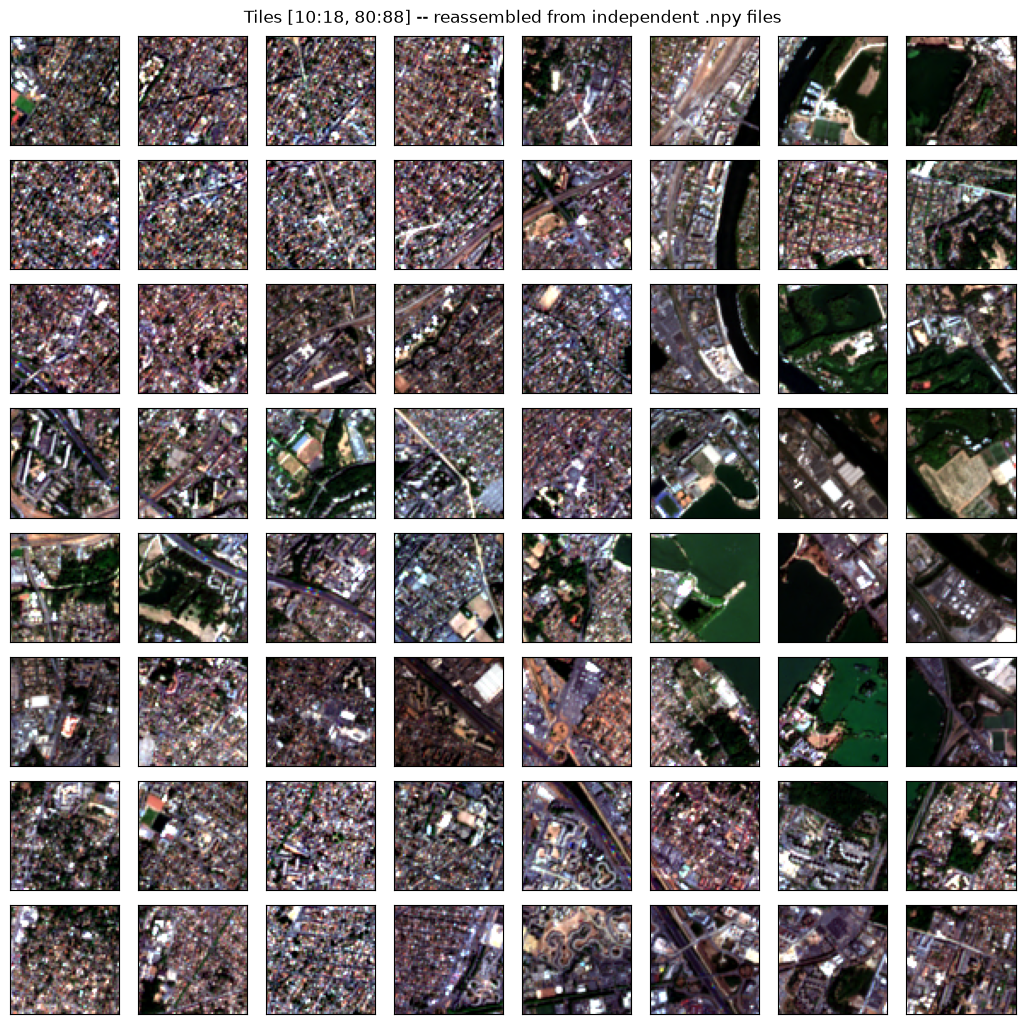

In [2]:
GRID_SIZE = 8
ROW_START, COL_START = 10, 80


def stretch(band, low=2, high=98):
    lo, hi = np.percentile(band, [low, high])
    return np.clip((band.astype(np.float32) - lo) / (hi - lo), 0, 1)


fig, axes = plt.subplots(GRID_SIZE, GRID_SIZE, figsize=(GRID_SIZE * 1.3, GRID_SIZE * 1.3))

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        row, col = ROW_START + i, COL_START + j
        tile = np.load(TILES_DIR / f"tile_{row:03d}_{col:03d}.npy")
        tile_stretched = np.stack([stretch(tile[..., c]) for c in range(3)], axis=-1)

        ax = axes[i, j]
        ax.imshow(tile_stretched)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle(f"Tiles [{ROW_START}:{ROW_START+GRID_SIZE}, {COL_START}:{COL_START+GRID_SIZE}] -- reassembled from independent .npy files")
plt.tight_layout()
plt.show()

## Classifying the same grid, properly calibrated this time

Notebook 03 previewed classification with a per-tile percentile stretch, which biased predictions (a mostly-agricultural crop came back mostly "Industrial") because the same real reflectance mapped to different pixel values depending on what else was in each tile.

`distributed_inference.py` fixes this with a single, fixed reflectance scale applied identically to every tile, rather than a per-tile stretch. Same idea here, on this notebook's 8x8 grid, for a visual before/after.

In [3]:
import json
import sys

import torch
from torch import nn
from torchvision.models import ResNet18_Weights, resnet18

sys.path.append("../scripts")
from distributed_inference import REFLECTANCE_MAX, calibrate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("../data/eurosat_stats.json") as f:
    stats = json.load(f)
classes = stats["classes"]
mean = torch.tensor(stats["mean"]).view(3, 1, 1).to(device)
std = torch.tensor(stats["std"]).view(3, 1, 1).to(device)

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model.load_state_dict(torch.load("../models/resnet18_eurosat_best.pt", map_location=device))
model = model.to(device).eval()

print(f"Model loaded, calibrating with REFLECTANCE_MAX={REFLECTANCE_MAX}")

Model loaded, calibrating with REFLECTANCE_MAX=5600


In [4]:
predictions = np.empty((GRID_SIZE, GRID_SIZE), dtype=int)

with torch.no_grad():
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            row, col = ROW_START + i, COL_START + j
            tile = np.load(TILES_DIR / f"tile_{row:03d}_{col:03d}.npy")

            tensor = torch.from_numpy(calibrate(tile).transpose(2, 0, 1)).float().to(device)
            tensor = ((tensor - mean) / std).unsqueeze(0)

            output = model(tensor)
            predictions[i, j] = output.argmax(dim=1).item()

print("Predicted class counts (this 8x8 grid):")
for c in range(len(classes)):
    count = (predictions == c).sum()
    if count > 0:
        print(f"  {classes[c]:25s} {count}")

Predicted class counts (this 8x8 grid):
  HerbaceousVegetation      28
  Highway                   5
  Industrial                3
  Pasture                   3
  PermanentCrop             1
  Residential               17
  River                     6
  SeaLake                   1


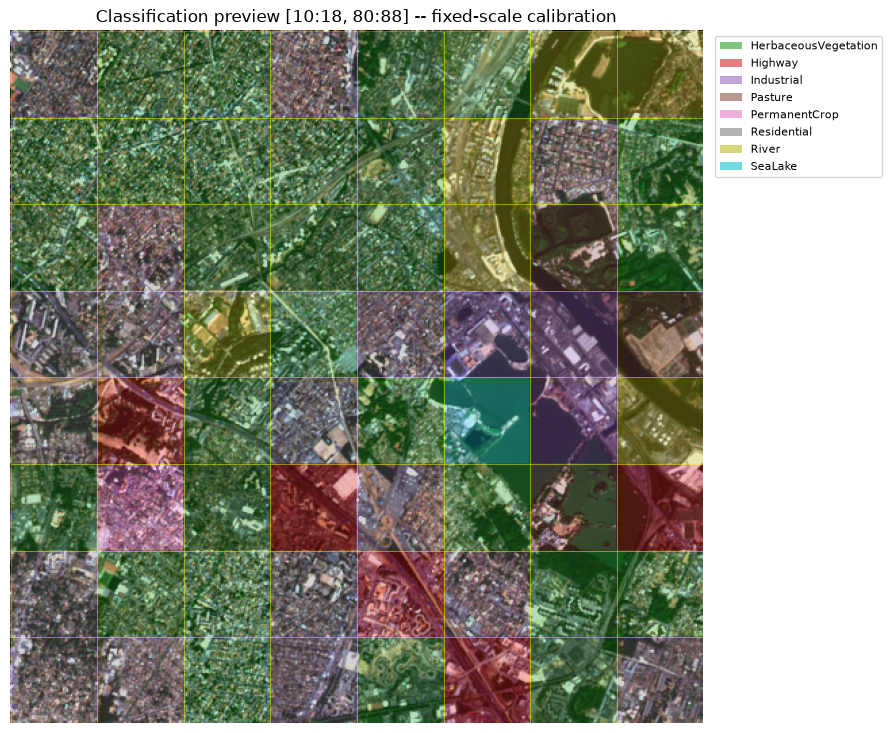

In [5]:
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, len(classes)))

fig, ax = plt.subplots(figsize=(9, 9))

# Reuse the same stretched RGB composite as the grid above, for a readable background
composite = np.zeros((GRID_SIZE * 64, GRID_SIZE * 64, 3))
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        row, col = ROW_START + i, COL_START + j
        tile = np.load(TILES_DIR / f"tile_{row:03d}_{col:03d}.npy")
        tile_stretched = np.stack([stretch(tile[..., c]) for c in range(3)], axis=-1)
        composite[i * 64 : (i + 1) * 64, j * 64 : (j + 1) * 64, :] = tile_stretched
ax.imshow(composite)

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        color = CLASS_COLORS[predictions[i, j]]
        rect = plt.Rectangle(
            (j * 64, i * 64), 64, 64,
            linewidth=0.6, edgecolor="yellow", facecolor=color, alpha=0.35,
        )
        ax.add_patch(rect)

present_classes = sorted(set(predictions.flatten()))
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=CLASS_COLORS[c], alpha=0.6, label=classes[c])
    for c in present_classes
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title(f"Classification preview [{ROW_START}:{ROW_START+GRID_SIZE}, {COL_START}:{COL_START+GRID_SIZE}] -- fixed-scale calibration")
ax.axis("off")
plt.tight_layout()
plt.show()